In [1]:
import sys
print("Using Python:", sys.executable)

Using Python: /opt/anaconda3/bin/python


In [2]:
from __future__ import annotations

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import sys
from pathlib import Path
current = Path.cwd()
for p in [current, *current.parents]:
    if (p / "src").exists():
        project_root = p
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

from src.signals import (build_signal_library,
                         select_signals,
                         signal_library_to_long,
                         get_available_signals)
from src.scoring import ( make_forward_returns,
                         score_signal_library,
                         summarize_signal_names)
from src.data_loader import (split_features_target, 
                             make_time_split_index, 
                             split_features_target,
                             split_by_index,
                             get_benchmark_returns)
from src.backtest import (generate_positions_from_proba,
                          strategy_returns_from_positions,
                          cumulative_returns,
                          evaluate_strategy,
                          backtest_continuous_strategy)
from src.utils import (generate_rolling_windows,
                       compute_ic_weights,
                       build_weighted_alpha_rank,
                       build_context_rank)

Project root: /Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model


## 1. Load baseline artifacts

In [3]:
config_dir = project_root / "config"
data_dir = project_root / "data" / "processed"
outputs_dir = project_root / "outputs"

with open(config_dir / "alpha_signals.json", "r") as f:
    ALPHA_SIGNALS = json.load(f)

with open(config_dir / "context_signals.json", "r") as f:
    CONTEXT_SIGNALS = json.load(f)

with open(config_dir / "strategy_config.json", "r") as f:
    STRATEGY_CONFIG = json.load(f)

alpha_library_full = pd.read_parquet(data_dir / "alpha_library.parquet")
context_library_full = pd.read_parquet(data_dir / "context_library.parquet")

print("Alpha signals:", ALPHA_SIGNALS)
print("Context signals:", CONTEXT_SIGNALS)
print("Strategy config:", STRATEGY_CONFIG)
print(alpha_library_full.shape, context_library_full.shape)

Alpha signals: ['breakout_dn_60', 'breakout_dn_20', 'rev_5']
Context signals: ['volavg_60', 'mkt_regime_vol_60', 'volavg_20', 'mkt_regime_vol_20', 'vol_60', 'vol_20']
Strategy config: {'rebalance_every': 21, 'smooth_window': 7, 'context_threshold': 0.6, 'position_cap': 0.05, 'target_vol': 0.1, 'max_leverage_scale': 2.0}
(2080, 90) (2080, 180)


In [4]:
clean_close_prices = pd.read_csv(project_root / "data" / "processed" / "notebook_02_data_prep" / "clean_close_prices.csv", index_col=0)
clean_close_prices.index = pd.to_datetime(clean_close_prices.index)
print(clean_close_prices.shape)
clean_close_prices.head()

(2080, 31)


,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,NFLX,NVDA,PEP,PG,SPY,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304173,69.343719,135.558258,177.699997,59.450500,21.086662,24.637497,197.220001,168.498184,102.899277,...,20.107000,4.928266,91.602791,72.824966,236.562180,188.755325,193.090485,108.111916,28.855198,58.580421
2018-01-03,40.297161,70.428848,136.183853,181.039993,60.209999,21.317259,24.555096,199.789993,170.520294,103.766556,...,20.504999,5.252614,91.362274,72.736610,238.058411,192.217896,195.116028,109.188217,29.106909,59.730961
2018-01-04,40.484329,70.027191,137.796402,183.220001,60.479500,21.324375,24.876453,200.690002,169.196091,105.136429,...,20.563000,5.280302,91.812271,73.250755,239.061844,194.623993,195.962891,109.594200,29.133242,59.813622
2018-01-05,40.945259,71.246223,138.933090,185.339996,61.457001,21.450729,24.991814,201.419998,167.988129,106.535881,...,20.999001,5.325049,92.076096,73.298973,240.654938,197.959396,199.699692,112.218857,29.305925,59.765404
2018-01-08,40.793179,70.104713,140.043381,185.039993,62.343498,21.502064,24.818777,202.740005,168.641266,107.284882,...,21.205000,5.488214,91.548485,73.684570,241.095032,198.282120,196.233566,112.672028,29.739092,60.034073


## 2. Build multi-horizon forward returns

In [5]:
forward_returns = {"fwd_1d": make_forward_returns(clean_close_prices, horizon=1),
                   "fwd_5d": make_forward_returns(clean_close_prices, horizon=5),
                   "fwd_10d": make_forward_returns(clean_close_prices, horizon=10),
                   "fwd_20d": make_forward_returns(clean_close_prices, horizon=20)}
for name, df in forward_returns.items():
    print(name, df.shape)

fwd_1d (2080, 31)
fwd_5d (2080, 31)
fwd_10d (2080, 31)
fwd_20d (2080, 31)


## 3. Score full alpha library across horizons

In [6]:
horizon_scores = {}
horizon_summaries = {}
for horizon_name, fwd_ret in forward_returns.items():
    scores = score_signal_library(alpha_library_full, fwd_ret, min_obs=60)
    summary = summarize_signal_names(scores, min_obs=60)
    summary = summary.sort_values("mean_ic", ascending=False).reset_index(drop=True)
    horizon_scores[horizon_name] = scores
    horizon_summaries[horizon_name] = summary

    print(f"\n=== {horizon_name} ===")
    print(summary.head(10))


=== fwd_1d ===
           signal  n_ticker_signal_pairs   mean_ic  median_ic  mean_hit_rate  \
0  breakout_dn_60                     30  0.037466   0.039829       0.539467   
1           rev_5                     30  0.030459   0.022763       0.501761   
2  breakout_dn_20                     30  0.028153   0.025684       0.534996   

   mean_spread  median_spread  
0     0.000138       0.000133  
1     0.001146       0.000872  
2     0.000170       0.000136  

=== fwd_5d ===
           signal  n_ticker_signal_pairs   mean_ic  median_ic  mean_hit_rate  \
0           rev_5                     30  0.038359   0.034827       0.494929   
1  breakout_dn_60                     30  0.035310   0.028887       0.594957   
2  breakout_dn_20                     30  0.030943   0.029377       0.576505   

   mean_spread  median_spread  
0     0.003415       0.003792  
1     0.000280       0.000213  
2     0.000370       0.000352  

=== fwd_10d ===
           signal  n_ticker_signal_pairs   mean_ic  m

## 4. Add family labels

In [7]:
def signal_family(signal_name: str) -> str:
    if signal_name.startswith("breakout_dn"):
        return "breakout_dn"
    elif signal_name.startswith("rev"):
        return "reversal"
    elif signal_name.startswith("volavg"):
        return "volavg"
    elif signal_name.startswith("vol_"):
        return "vol"
    elif signal_name.startswith("mkt_regime_vol"):
        return "mkt_vol"
    else:
        return "other"

## 5. Extract top-2 per family for each horizon

In [8]:
for horizon_name in horizon_summaries:
    horizon_summaries[horizon_name]["family"] = (horizon_summaries[horizon_name]["signal"].apply(signal_family))

top_by_horizon = {}
for horizon_name, summary in horizon_summaries.items():
    top_signals = (summary.sort_values("mean_ic", ascending=False).groupby("family").head(2).copy())
    top_by_horizon[horizon_name] = top_signals
    print(f"\n=== Top signals: {horizon_name} ===")
    display(top_signals[["signal", "family", "mean_ic", "mean_hit_rate"]])


=== Top signals: fwd_1d ===


,signal,family,mean_ic,mean_hit_rate
0,breakout_dn_60,breakout_dn,0.037466,0.539467
1,rev_5,reversal,0.030459,0.501761
2,breakout_dn_20,breakout_dn,0.028153,0.534996



=== Top signals: fwd_5d ===


,signal,family,mean_ic,mean_hit_rate
0,rev_5,reversal,0.038359,0.494929
1,breakout_dn_60,breakout_dn,0.035310,0.594957
2,breakout_dn_20,breakout_dn,0.030943,0.576505



=== Top signals: fwd_10d ===


,signal,family,mean_ic,mean_hit_rate
0,breakout_dn_60,breakout_dn,0.039585,0.646997
1,rev_5,reversal,0.034475,0.496245
2,breakout_dn_20,breakout_dn,0.032906,0.608375



=== Top signals: fwd_20d ===


,signal,family,mean_ic,mean_hit_rate
0,breakout_dn_60,breakout_dn,0.043918,0.640841
1,rev_5,reversal,0.041063,0.493626
2,breakout_dn_20,breakout_dn,0.031749,0.621579


## 6. Compare selected alpha signals across horizons

In [9]:
comparison_rows = []
for horizon_name, summary in horizon_summaries.items():
    subset = summary[summary["signal"].isin(ALPHA_SIGNALS + CONTEXT_SIGNALS)].copy()
    subset["horizon"] = horizon_name
    comparison_rows.append(subset)

signal_horizon_comparison = pd.concat(comparison_rows, ignore_index=True)
signal_horizon_comparison = signal_horizon_comparison.sort_values(["signal", "horizon"]).reset_index(drop=True)
best_horizon_map = (signal_horizon_comparison.sort_values("mean_ic", ascending=False).groupby("signal").first()["horizon"].to_dict())
print(best_horizon_map)

{'breakout_dn_20': 'fwd_10d', 'breakout_dn_60': 'fwd_20d', 'rev_5': 'fwd_20d'}


## 7. Compare top signals across horizons

In [10]:
top_comparison_rows = []
for horizon_name, top_df in top_by_horizon.items():
    temp = top_df.copy()
    temp["horizon"] = horizon_name
    top_comparison_rows.append(temp)

top_signal_comparison = pd.concat(top_comparison_rows, ignore_index=True)
top_signal_comparison = top_signal_comparison.sort_values(["family", "horizon", "mean_ic"],ascending=[True, True, False]).reset_index(drop=True)
top_signal_comparison

,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread,family,horizon
0,breakout_dn_60,30,0.039585,0.036079,0.646997,0.000408,0.000385,breakout_dn,fwd_10d
1,breakout_dn_20,30,0.032906,0.029953,0.608375,0.000539,0.000460,breakout_dn,fwd_10d
2,breakout_dn_60,30,0.037466,0.039829,0.539467,0.000138,0.000133,breakout_dn,fwd_1d
3,breakout_dn_20,30,0.028153,0.025684,0.534996,0.000170,0.000136,breakout_dn,fwd_1d
4,breakout_dn_60,30,0.043918,0.040046,0.640841,0.000542,0.000611,breakout_dn,fwd_20d
5,breakout_dn_20,30,0.031749,0.031313,0.621579,0.000652,0.000644,breakout_dn,fwd_20d
6,breakout_dn_60,30,0.035310,0.028887,0.594957,0.000280,0.000213,breakout_dn,fwd_5d
7,breakout_dn_20,30,0.030943,0.029377,0.576505,0.000370,0.000352,breakout_dn,fwd_5d
8,rev_5,30,0.034475,0.030312,0.496245,0.004921,0.003840,reversal,fwd_10d
9,rev_5,30,0.030459,0.022763,0.501761,0.001146,0.000872,reversal,fwd_1d


## 8. Heatmap of mean IC by signal and horizon

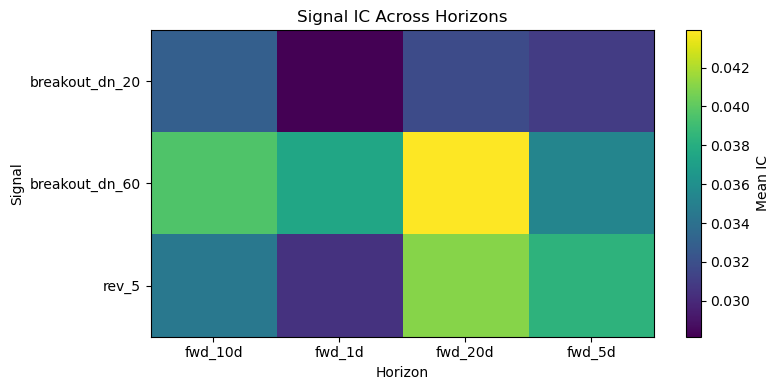

In [11]:
pivot_ic = signal_horizon_comparison.pivot(index="signal", columns="horizon", values="mean_ic")

plt.figure(figsize=(8, max(4, len(pivot_ic) * 0.4)))
plt.imshow(pivot_ic.values, aspect="auto")
plt.colorbar(label="Mean IC")
plt.xticks(range(len(pivot_ic.columns)), pivot_ic.columns)
plt.yticks(range(len(pivot_ic.index)), pivot_ic.index)
plt.xlabel("Horizon")
plt.ylabel("Signal")
plt.title("Signal IC Across Horizons")
plt.tight_layout()
plt.show()

# Midpoint Conclusion 1:

The multi-horizon signal evaluation reveals that all selected signals exhibit stronger predictive power at medium horizons (10–20 days), with peak performance generally occurring at 20 days. 

Breakout signals show consistent improvement as the horizon increases, while the reversal signal demonstrates delayed mean-reversion behavior rather than short-term predictability. 

These findings indicate that the signal set is inherently medium-term in nature and that prior underperformance at the 1-day horizon was due to misalignment between signal dynamics and execution frequency. This motivates a transition toward a horizon-aware alpha construction framework.

## 9. Build multi-horizon summaries for selected signals

In [12]:
forward_returns = {"fwd_5d": make_forward_returns(clean_close_prices, horizon=5),
                   "fwd_10d": make_forward_returns(clean_close_prices, horizon=10),
                   "fwd_20d": make_forward_returns(clean_close_prices, horizon=20)}
comparison_rows = []
for horizon_name, fwd_ret in forward_returns.items():
    scores = score_signal_library(alpha_library_full, fwd_ret, min_obs=60)
    summary = summarize_signal_names(scores, min_obs=60)

    subset = summary[summary["signal"].isin(ALPHA_SIGNALS)].copy()
    subset["horizon"] = horizon_name
    comparison_rows.append(subset)

signal_horizon_comparison = pd.concat(comparison_rows, ignore_index=True)
signal_horizon_comparison = signal_horizon_comparison.sort_values(["signal", "mean_ic"], ascending=[True, False]).reset_index(drop=True)
signal_horizon_comparison

,signal,n_ticker_signal_pairs,mean_ic,median_ic,mean_hit_rate,mean_spread,median_spread,horizon
0,breakout_dn_20,30,0.032906,0.029953,0.608375,0.000539,0.000460,fwd_10d
1,breakout_dn_20,30,0.031749,0.031313,0.621579,0.000652,0.000644,fwd_20d
2,breakout_dn_20,30,0.030943,0.029377,0.576505,0.000370,0.000352,fwd_5d
3,breakout_dn_60,30,0.043918,0.040046,0.640841,0.000542,0.000611,fwd_20d
4,breakout_dn_60,30,0.039585,0.036079,0.646997,0.000408,0.000385,fwd_10d
5,breakout_dn_60,30,0.035310,0.028887,0.594957,0.000280,0.000213,fwd_5d
6,rev_5,30,0.041063,0.054046,0.493626,0.007012,0.010423,fwd_20d
7,rev_5,30,0.038359,0.034827,0.494929,0.003415,0.003792,fwd_5d
8,rev_5,30,0.034475,0.030312,0.496245,0.004921,0.003840,fwd_10d


## 10. Choose best horizon for each signal

In [13]:
best_signal_horizons = (signal_horizon_comparison.sort_values("mean_ic", ascending=False).groupby("signal").first().reset_index())
best_signal_horizons = best_signal_horizons[["signal", "horizon", "mean_ic"]]
horizon_days_series = best_signal_horizons["horizon"].str.extract(r"fwd_(\d+)d")[0]
bad_mask = horizon_days_series.isna()
if bad_mask.any():
    print("⚠️ Found horizon values that do NOT match expected pattern 'fwd_Xd':")
    print(best_signal_horizons.loc[bad_mask, ["signal", "horizon"]])
    raise ValueError("Fix horizon format before proceeding.")
best_signal_horizons["horizon_days"] = horizon_days_series.astype(int)
best_signal_horizons = (best_signal_horizons.sort_values("mean_ic", ascending=False).reset_index(drop=True))
display(best_signal_horizons)

,signal,horizon,mean_ic,horizon_days
0,breakout_dn_60,fwd_20d,0.043918,20
1,rev_5,fwd_20d,0.041063,20
2,breakout_dn_20,fwd_10d,0.032906,10


## 11. Build weights from best signal-horizon pairs

In [14]:
best_signal_horizons["raw_weight"] = best_signal_horizons["mean_ic"].clip(lower=0)
if best_signal_horizons["raw_weight"].sum() == 0:
    best_signal_horizons["raw_weight"] = 1.0

best_signal_horizons["weight"] = (best_signal_horizons["raw_weight"] / best_signal_horizons["raw_weight"].sum())
best_signal_horizons

,signal,horizon,mean_ic,horizon_days,raw_weight,weight
0,breakout_dn_60,fwd_20d,0.043918,20,0.043918,0.372545
1,rev_5,fwd_20d,0.041063,20,0.041063,0.348323
2,breakout_dn_20,fwd_10d,0.032906,10,0.032906,0.279132


## 12. Build signal specific horizon alpha

In [15]:
alpha_components = []
alpha_component_metadata = []
for _, row in best_signal_horizons.iterrows():
    sig = row["signal"]
    horizon_name = row["horizon"]
    horizon_days = row["horizon_days"]
    w = row["weight"]
    sig_df = alpha_library_full.xs(sig, level="signal", axis=1)
    sig_rank = sig_df.rank(axis=1, pct=True)
    alpha_components.append(sig_rank * w)
    alpha_component_metadata.append({
        "signal": sig,
        "horizon": horizon_name,
        "horizon_days": horizon_days,
        "weight": w,
    })

alpha_signal_specific_score = sum(alpha_components)
alpha_signal_specific_rank = alpha_signal_specific_score.rank(axis=1, pct=True)
alpha_signal_specific_rank.head()

# audit: preserve signal-horizon-weight mapping used in alpha construction
display(pd.DataFrame(alpha_component_metadata))
display(best_signal_horizons[["signal", "horizon", "horizon_days", "mean_ic", "raw_weight", "weight"]])

,signal,horizon,horizon_days,weight
0,breakout_dn_60,fwd_20d,20,0.372545
1,rev_5,fwd_20d,20,0.348323
2,breakout_dn_20,fwd_10d,10,0.279132


,signal,horizon,horizon_days,mean_ic,raw_weight,weight
0,breakout_dn_60,fwd_20d,20,0.043918,0.043918,0.372545
1,rev_5,fwd_20d,20,0.041063,0.041063,0.348323
2,breakout_dn_20,fwd_10d,10,0.032906,0.032906,0.279132


## 13. Build context rank

In [16]:
context_rank_full = build_context_rank(context_library=context_library_full, context_signals=CONTEXT_SIGNALS)
context_rank_full.head()

ticker,AAPL,ABBV,ACN,ADBE,AMZN,AVGO,BAC,BRK-B,COST,CRM,...,MSFT,NFLX,NVDA,PEP,PG,TMO,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
portfolio_forward_target = None
for _, row in best_signal_horizons.iterrows():
    weighted_target = forward_returns[row["horizon"]] * row["weight"]
    if portfolio_forward_target is None:
        portfolio_forward_target = weighted_target.copy()
    else:
        portfolio_forward_target = portfolio_forward_target.add(weighted_target, fill_value=0.0)
portfolio_forward_target = portfolio_forward_target.reindex(columns=alpha_signal_specific_rank.columns)
valid_start = max(alpha_signal_specific_rank.dropna(how="all").index.min(), context_rank_full.dropna(how="all").index.min(), portfolio_forward_target.dropna(how="all").index.min())
alpha_signal_specific_rank_aligned = alpha_signal_specific_rank.loc[valid_start:]
context_rank_full_aligned = context_rank_full.loc[valid_start:]
portfolio_forward_target_aligned = portfolio_forward_target.loc[valid_start:]
print("Valid start:", valid_start)
print(alpha_signal_specific_rank_aligned.shape)
print(context_rank_full_aligned.shape)
print(portfolio_forward_target_aligned.shape)

Valid start: 2018-03-29 00:00:00
(2020, 30)
(2020, 30)
(2020, 30)


In [18]:
res_signal_specific = backtest_continuous_strategy(alpha_rank=alpha_signal_specific_rank_aligned,
                                                   forward_returns=portfolio_forward_target_aligned,
                                                   context_rank=context_rank_full_aligned,
                                                   context_mode="filter",
                                                   context_threshold=STRATEGY_CONFIG["context_threshold"],
                                                   position_cap=STRATEGY_CONFIG["position_cap"],
                                                   smooth_window=STRATEGY_CONFIG["smooth_window"],
                                                   rebalance_every=STRATEGY_CONFIG["rebalance_every"],
                                                   min_trade_threshold=0.00,
                                                   market_neutral=False,
                                                   normalize_gross=True,
                                                   target_vol=STRATEGY_CONFIG["target_vol"],
                                                   vol_lookback=60,
                                                   max_leverage_scale=STRATEGY_CONFIG["max_leverage_scale"],
                                                   cost_per_turnover=0.0005)
print(f"Sharpe: {res_signal_specific['sharpe']:.3f}")
print(f"Max DD: {res_signal_specific['max_drawdown']:.2%}")
print(f"Return: {res_signal_specific['total_return']:.2%}")
print(f"Avg Turnover: {res_signal_specific['turnover'].mean():.3f}")

Sharpe: 1.406
Max DD: -67.86%
Return: 287.13%
Avg Turnover: 0.038


In [19]:
print("First valid alpha rank:", alpha_signal_specific_rank.dropna(how="all").index.min())
print("First valid context rank:", context_rank_full.dropna(how="all").index.min())

First valid alpha rank: 2018-01-10 00:00:00
First valid context rank: 2018-03-29 00:00:00


In [24]:
processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

phase2_dir = project_root / "data" / "processed" / "Phase2_Signal Expansion"
phase2_dir.mkdir(parents=True, exist_ok=True)

alpha_library_path = phase2_dir / "notebook_01_Multi-Horizon Signal Extraction" / "alpha_library_full.parquet"
alpha_library_full.to_parquet(alpha_library_path)

context_library_path = phase2_dir / "notebook_01_Multi-Horizon Signal Extraction" / "context_library_full.parquet"

if "context_library_full" in globals() and context_library_full is not None:
    context_library_full.to_parquet(context_library_path)
    print(f"Saved: {context_library_path}")
else:
    print("Skipped: context_library_full not found")

print(f"Saved: {alpha_library_path}")

Saved: /Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model/data/processed/Phase2_Signal Expansion/notebook_01_Multi-Horizon Signal Extraction/context_library_full.parquet
Saved: /Users/AnyiXu_1/Desktop/multi-factor-equity-alpha-model/data/processed/Phase2_Signal Expansion/notebook_01_Multi-Horizon Signal Extraction/alpha_library_full.parquet
